# 02 - Variational AutoEncoder (VAE)

Treina um VAE para gerar imagens sintéticas de borboletas.

**Estrutura:**
1. Setup
2. Dados
3. Baseline VAE (hiperparâmetros por defeito)
4. Avaliação: SSIM, FID, IS
5. Grid Search de hiperparâmetros
6. Treino final com melhor config
7. Gerar dataset aumentado
8. Retreinar Baseline CNN + comparar

## 1. Setup & Imports

In [ ]:
import os, sys, json, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as T
import torchvision.utils as vutils

from sklearn.metrics import accuracy_score, f1_score
from skimage.metrics import structural_similarity as ssim_metric
import kagglehub

# Install torchmetrics if needed
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.inception import InceptionScore
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torchmetrics[image]', '-q'])
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.inception import InceptionScore

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():            device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                    device = torch.device('cpu')
print('Device:', device)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
for c in [os.path.join(NOTEBOOK_DIR,'../src'), os.path.join(NOTEBOOK_DIR,'src'),
          '/Applications/Universidade/4ano_2semestre/ACA/projeto2/aml-butterfly-generative-augmentation/src']:
    c = os.path.abspath(c)
    if os.path.isdir(c) and c not in sys.path:
        sys.path.append(c); break

from dataset import ButterflyDataset
from transforms import get_transforms
from models import BaselineCNN
from autoencoder import VAE, vae_loss
from utils import get_splits, get_class_mapping, GLOBAL_SEED
print('OK')

Device: mps
OK


## 2. Dados

In [ ]:
path = kagglehub.competition_download('aca-tp-2')
train_dir = os.path.join(path, 'train')

df = pd.read_csv(os.path.join(path, 'train.csv'))[['filename', 'label']]
train_df, val_df = get_splits(df, seed=GLOBAL_SEED)
class_to_idx, idx_to_class, classes = get_class_mapping(df)
NUM_CLASSES = len(classes)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Classes: {NUM_CLASSES}')

Train: 4159 | Val: 1040 | Classes: 75


## 3. Funções Auxiliares

In [ ]:
IMAGE_SIZE = 64
BATCH_SIZE = 64

# Transform para o VAE: normaliza para [-1, 1] (compativel com Tanh no decoder)
vae_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.ToTensor(),
    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])
vae_transform_val = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

train_ds = ButterflyDataset(df=train_df, img_dir=train_dir, transform=vae_transform)
val_ds   = ButterflyDataset(df=val_df,   img_dir=train_dir, transform=vae_transform_val)
train_ld = data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_ld   = data.DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

def train_vae(latent_dim, beta, lr, epochs=40, patience=5, ckpt_path=None, save_every=10):
    """
    Treina um VAE com suporte a checkpoints.
    Args:
        ckpt_path  : str | None — caminho base para guardar checkpoints
                     (ex: "../outputs/ckpts/vae_best"). Se None, sem checkpoints.
        save_every : int — guardar checkpoint a cada N epochs.
    """
    vae = VAE(latent_dim=latent_dim).to(device)
    opt = optim.Adam(vae.parameters(), lr=lr)
    best_loss, no_imp, best_state = float("inf"), 0, None
    history = []
    start_epoch = 0
    val_recon = 0.0

    # ── Retomar de checkpoint, se existir ──────────────────────────────────
    if ckpt_path is not None:
        import glob
        existing = sorted(glob.glob(f"{ckpt_path}_epoch_*.pt"))
        if existing:
            latest = existing[-1]
            print(f"  [Checkpoint] A retomar de: {latest}")
            ckpt = torch.load(latest, map_location=device)
            vae.load_state_dict(ckpt["model_state"])
            opt.load_state_dict(ckpt["opt_state"])
            best_loss   = ckpt["best_loss"]
            no_imp      = ckpt["no_imp"]
            best_state  = ckpt["best_state"]
            history     = ckpt["history"]
            start_epoch = ckpt["epoch"] + 1
            val_recon   = ckpt.get("val_recon", 0.0)
            print(f"  [Checkpoint] Epoch {start_epoch}/{epochs} | best_loss={best_loss:.4f}")
        os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

    for epoch in range(start_epoch, epochs):
        vae.train(); ep_loss = 0
        for imgs, _ in train_ld:
            imgs = imgs.to(device)
            opt.zero_grad()
            recon, mu, lv = vae(imgs)
            loss, _, _ = vae_loss(recon, imgs, mu, lv, beta=beta)
            loss.backward(); opt.step()
            ep_loss += loss.item()
        ep_loss /= len(train_ld)
        # Val loss
        vae.eval(); val_loss = 0; val_recon = 0
        with torch.no_grad():
            for imgs, _ in val_ld:
                imgs = imgs.to(device)
                recon, mu, lv = vae(imgs)
                l, recon_l, _ = vae_loss(recon, imgs, mu, lv, beta=beta)
                val_loss += l.item(); val_recon += recon_l.item()
        val_loss /= len(val_ld); val_recon /= len(val_ld)
        history.append({"epoch": epoch+1, "train_loss": ep_loss, "val_loss": val_loss})
        if val_loss < best_loss:
            best_loss = val_loss; no_imp = 0
            best_state = {k: v.cpu().clone() for k, v in vae.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"  [EarlyStopping] Epoch {epoch+1}/{epochs}")
                break

        # ── Guardar checkpoint periodicamente ──────────────────────────────
        if ckpt_path is not None and (epoch + 1) % save_every == 0:
            ckpt_file = f"{ckpt_path}_epoch_{epoch+1:04d}.pt"
            torch.save({
                "epoch":       epoch,
                "model_state": vae.state_dict(),
                "opt_state":   opt.state_dict(),
                "best_loss":   best_loss,
                "no_imp":      no_imp,
                "best_state":  best_state,
                "history":     history,
                "val_recon":   val_recon,
            }, ckpt_file)
            print(f"  [Checkpoint] Guardado: {ckpt_file}")

    vae.load_state_dict(best_state); vae.to(device)
    return vae, best_loss, history, val_recon

print("Auxiliary functions ready.")

Auxiliary functions ready.


## 4. Baseline VAE

Treino com hiperparâmetros por defeito: `latent_dim=128`, `beta=1.0`, `lr=1e-3`.

In [ ]:
print('Training Baseline VAE (latent_dim=128, beta=1.0, lr=1e-3)...')
vae_baseline, baseline_val_loss, baseline_hist, _ = train_vae(latent_dim=128, beta=1.0, lr=1e-3, epochs=40, patience=5)

Training Baseline VAE (latent_dim=128, beta=1.0, lr=1e-3)...
Baseline VAE best val loss: 823.7070


### 4a. Loss Curve (Baseline VAE)

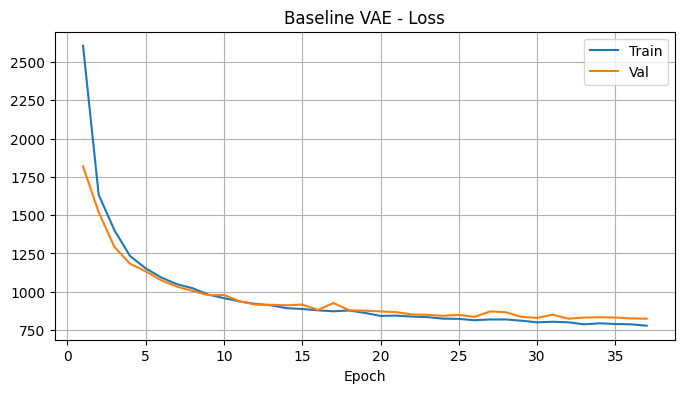

In [ ]:
hist_df = pd.DataFrame(baseline_hist)
plt.figure(figsize=(8,4))
plt.plot(hist_df['epoch'], hist_df['train_loss'], label='Train')
plt.plot(hist_df['epoch'], hist_df['val_loss'], label='Val')
plt.title('Baseline VAE - Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/vae_baseline_loss.png', dpi=150); plt.show()

### 4b. Reconstruções Visuais

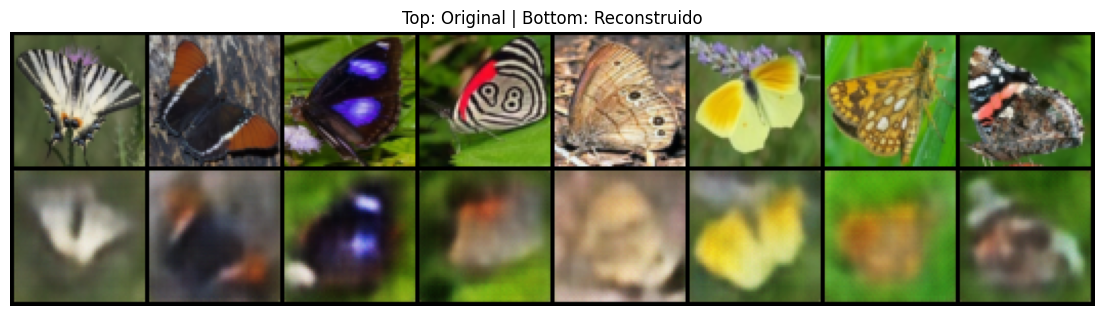

In [ ]:
vae_baseline.eval()
sample, _ = next(iter(val_ld))
sample = sample[:8].to(device)
with torch.no_grad():
    recon = vae_baseline.reconstruct(sample)

grid = vutils.make_grid(torch.cat([denorm(sample.cpu()), denorm(recon.cpu())]), nrow=8, padding=2)
plt.figure(figsize=(14, 4))
plt.imshow(grid.permute(1,2,0))
plt.title('Top: Original | Bottom: Reconstruido'); plt.axis('off')
plt.savefig('../outputs/vae_reconstructions.png', dpi=150, bbox_inches='tight'); plt.show()

### 4c. Amostras Geradas

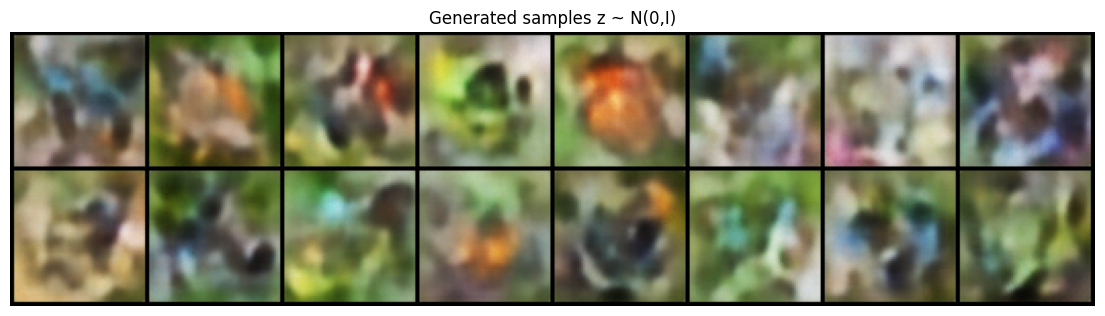

In [ ]:
with torch.no_grad():
    gen = vae_baseline.generate(n=16, device=device)
grid = vutils.make_grid(denorm(gen.cpu()), nrow=8, padding=2)
plt.figure(figsize=(14, 4))
plt.imshow(grid.permute(1,2,0))
plt.title('Generated samples z ~ N(0,I)'); plt.axis('off')
plt.savefig('../outputs/vae_generated.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Métricas de Avaliação do Modelo Generativo

Os professores pedem métricas da literatura para avaliar a qualidade das imagens geradas:
- **SSIM** (Structural Similarity Index) — qualidade das reconstruções
- **FID** (Fréchet Inception Distance) — distância entre distribuições real vs gerada (menor = melhor)
- **IS** (Inception Score) — qualidade e diversidade das imagens geradas (maior = melhor)

In [ ]:
import numpy as np
from skimage.metrics import structural_similarity

# ── SSIM sobre as reconstruções do val set ─────────────────────────────────────
vae_baseline.eval()
ssim_scores = []
with torch.no_grad():
    for imgs, _ in val_ld:
        imgs = imgs.to(device)
        recon = vae_baseline.reconstruct(imgs)
        orig_np  = denorm(imgs).cpu().permute(0,2,3,1).numpy()
        recon_np = denorm(recon).cpu().permute(0,2,3,1).numpy()
        for o, r in zip(orig_np, recon_np):
            score = structural_similarity(o, r, data_range=1.0, channel_axis=2)
            ssim_scores.append(score)
mean_ssim = np.mean(ssim_scores)
print(f'SSIM (val reconstructions): {mean_ssim:.4f}  (range [0,1], higher=better)')

SSIM (val reconstructions): 0.4769  (range [0,1], higher=better)


In [ ]:
# ── FID & IS usando torchmetrics ──────────────────────────────────────────────
# NOTA: O backend 'mps' da Apple nao suporta tensores float64 que o torchmetrics usa.
# Solucao: Forcar o torchmetrics a correr no CPU (o 'device' continua a ser usado 
# para a rede gerar as imagens muito rapidamente).

metric_device = torch.device('cpu') if device.type == 'mps' else device

N_GEN = 500  # numero de imagens geradas para calcular FID e IS

fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(metric_device)
is_metric  = InceptionScore(normalize=True).to(metric_device)

fid_metric.reset(); is_metric.reset()

# Update com imagens REAIS (val set)
for imgs, _ in val_ld:
    real_uint8 = (denorm(imgs) * 255).clamp(0,255).to(torch.uint8).to(metric_device)
    fid_metric.update(real_uint8, real=True)

# Update com imagens GERADAS
vae_baseline.eval()
generated_all = []
with torch.no_grad():
    for start in range(0, N_GEN, BATCH_SIZE):
        n = min(BATCH_SIZE, N_GEN - start)
        z = torch.randn(n, vae_baseline.latent_dim, device=device)
        gen = vae_baseline.decoder(z)
        gen_uint8 = (denorm(gen) * 255).clamp(0,255).to(torch.uint8).to(metric_device)
        fid_metric.update(gen_uint8, real=False)
        is_metric.update(gen_uint8)
        generated_all.append(denorm(gen).cpu())

fid_score = fid_metric.compute().item()
is_mean, is_std = is_metric.compute()
is_mean, is_std = is_mean.item(), is_std.item()

print(f'FID  : {fid_score:.2f}  (lower is better)')
print(f'IS   : {is_mean:.2f} +/- {is_std:.2f}  (higher is better)')
print(f'SSIM : {mean_ssim:.4f}  (higher is better)')

baseline_metrics = {'ssim': float(mean_ssim), 'fid': float(fid_score), 'is_mean': float(is_mean), 'is_std': float(is_std)}
with open('../outputs/vae_baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=2)
print('Baseline VAE metrics saved.')

/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


FID  : 4.04  (lower is better)
IS   : 2.39 +/- 0.13  (higher is better)
SSIM : 0.4769  (higher is better)
Baseline VAE metrics saved.


## 6. Grid Search de Hiperparâmetros

Exploramos sistematicamente combinações de:
- `latent_dim` — tamanho do espaço latente
- `beta` — peso do termo KL (controla o trade-off disentanglement vs reconstrução)
- `lr` — taxa de aprendizagem

Métrica de selecção: **Val Loss** (mais rápido que FID para grid search).

In [ ]:
PARAM_GRID = {
    'latent_dim': [64, 128, 256, 512],
    'beta':       [0.5, 1.0, 2.0],
    'lr':         [1e-3, 5e-4, 1e-4],
}

combinations = list(itertools.product(
    PARAM_GRID['latent_dim'],
    PARAM_GRID['beta'],
    PARAM_GRID['lr'],
))
print(f'Total combinations: {len(combinations)}')
print('Grid Search started (usando 15 épocas + patience=3 por combinação)...')

grid_results = []
for latent_dim, beta, lr in combinations:
    print(f'  latent_dim={latent_dim}, beta={beta}, lr={lr} ... ', end='')
    _, val_loss, _, val_recon = train_vae(latent_dim=latent_dim, beta=beta, lr=lr, epochs=15, patience=3)
    grid_results.append({'latent_dim': latent_dim, 'beta': beta, 'lr': lr, 'val_loss': val_loss, 'val_recon': val_recon})
    print(f'val_loss={val_loss:.4f}, val_recon={val_recon:.4f}')

grid_df = pd.DataFrame(grid_results).sort_values('val_recon')
print('\nGrid Search Results:')

Total combinations: 36
Grid Search started (usando 15 épocas + patience=3 por combinação)...
  latent_dim=64, beta=0.5, lr=0.001 ... val_loss=908.9095
  latent_dim=64, beta=0.5, lr=0.0005 ... val_loss=946.3114
  latent_dim=64, beta=0.5, lr=0.0001 ... val_loss=1020.7841
  latent_dim=64, beta=1.0, lr=0.001 ... val_loss=1006.0351
  latent_dim=64, beta=1.0, lr=0.0005 ... val_loss=956.3081
  latent_dim=64, beta=1.0, lr=0.0001 ... val_loss=1056.2541
  latent_dim=64, beta=2.0, lr=0.001 ... val_loss=1059.7684
  latent_dim=64, beta=2.0, lr=0.0005 ... val_loss=1057.1227
  latent_dim=64, beta=2.0, lr=0.0001 ... val_loss=1200.7412
  latent_dim=128, beta=0.5, lr=0.001 ... val_loss=783.1717
  latent_dim=128, beta=0.5, lr=0.0005 ... val_loss=808.2448
  latent_dim=128, beta=0.5, lr=0.0001 ... val_loss=960.6764
  latent_dim=128, beta=1.0, lr=0.001 ... val_loss=925.1705
  latent_dim=128, beta=1.0, lr=0.0005 ... val_loss=895.5041
  latent_dim=128, beta=1.0, lr=0.0001 ... val_loss=1080.7522
  latent_dim=1

In [ ]:
from IPython import display
# ── Selecção do melhor config baseada em FID (subset rápido de 200 imgs) ──
# O val_loss nem sempre correlaciona com qualidade visual;
# o FID mede directamente a distância entre distribuição real e gerada.
FID_SUBSET = 1040  # amostras reais para FID rápido no grid

top_k = grid_df.head(6)  # Avaliamos os top-6 agora pelo val_recon  # avaliar apenas os top-6 do val_loss para não demorar demasiado
print(f'A calcular FID para os top-{len(top_k)} configs...')

from torchmetrics.image.fid import FrechetInceptionDistance as _FID
metric_device_gs = 'cpu'
fid_gs = _FID(feature=64).to(metric_device_gs)

# carregar imgs reais (subset)
real_imgs_for_fid = []
for imgs, _ in val_ld:
    real_imgs_for_fid.append(imgs)
    if sum(x.shape[0] for x in real_imgs_for_fid) >= FID_SUBSET:
        break
real_imgs_cat = torch.cat(real_imgs_for_fid, dim=0)[:FID_SUBSET]
real_u8 = (denorm(real_imgs_cat) * 255).clamp(0, 255).to(torch.uint8).to(metric_device_gs)

fid_scores = []
for _, row in top_k.iterrows():
    ld, b, lr_ = int(row['latent_dim']), float(row['beta']), float(row['lr'])
    vae_tmp, _, _, _ = train_vae(latent_dim=ld, beta=b, lr=lr_, epochs=20, patience=4)
    vae_tmp.eval()
    fid_gs.reset()
    fid_gs.update(real_u8, real=True)
    with torch.no_grad():
        z = torch.randn(FID_SUBSET, ld, device=device)
        gen = vae_tmp.decoder(z)
        gen_u8 = (denorm(gen) * 255).clamp(0, 255).to(torch.uint8).to(metric_device_gs)
        fid_gs.update(gen_u8, real=False)
    fid_val = fid_gs.compute().item()
    fid_scores.append({'latent_dim': ld, 'beta': b, 'lr': lr_, 'val_loss': row['val_loss'], 'fid': fid_val})
    print(f'  latent_dim={ld}, beta={b}, lr={lr_} → FID={fid_val:.4f}')

fid_grid_df = pd.DataFrame(fid_scores).sort_values('fid')
print('\nTop configs por FID:')
print(fid_grid_df)

best = fid_grid_df.iloc[0]
BEST_LATENT = int(best['latent_dim'])
BEST_BETA   = float(best['beta'])
BEST_LR     = float(best['lr'])
print(f'\nMelhor config (por FID): latent_dim={BEST_LATENT}, beta={BEST_BETA}, lr={BEST_LR}')

A calcular FID para os top-6 configs...
  latent_dim=128, beta=0.5, lr=0.001 → FID=4.3135
  latent_dim=128, beta=0.5, lr=0.0005 → FID=3.5644
  latent_dim=256, beta=0.5, lr=0.0005 → FID=3.8129
  latent_dim=256, beta=0.5, lr=0.001 → FID=4.7731
  latent_dim=512, beta=0.5, lr=0.0005 → FID=4.3099
  latent_dim=128, beta=1.0, lr=0.0005 → FID=3.5726

Top configs por FID:
   latent_dim  beta      lr    val_loss       fid
1         128   0.5  0.0005  808.244762  3.564389
5         128   1.0  0.0005  895.504086  3.572624
2         256   0.5  0.0005  808.853577  3.812898
4         512   0.5  0.0005  847.117687  4.309934
0         128   0.5  0.0010  783.171652  4.313465
3         256   0.5  0.0010  818.938078  4.773086

Melhor config (por FID): latent_dim=128, beta=0.5, lr=0.0005
  val_loss=808.2448  |  FID=3.5644


## 7. Treino Final com Melhor Configuração

In [ ]:
print(f'Training best VAE: latent_dim={BEST_LATENT}, beta={BEST_BETA}, lr={BEST_LR}')

CKPT_DIR = '../outputs/ckpts'
os.makedirs(CKPT_DIR, exist_ok=True)

vae_best, best_val_loss, best_hist, _ = train_vae(
    latent_dim=BEST_LATENT, beta=BEST_BETA, lr=BEST_LR,
    epochs=60, patience=7,
    ckpt_path=f'{CKPT_DIR}/vae_best',  # guarda checkpoint a cada 10 epochs
    save_every=10,
)
print(f'Best VAE final val loss: {best_val_loss:.4f}')

os.makedirs('../outputs/models', exist_ok=True)
torch.save(vae_best.state_dict(), '../outputs/models/vae_best.pth')

# Save best config
with open('../outputs/vae_best_config.json', 'w') as f:
    json.dump({'latent_dim': BEST_LATENT, 'beta': BEST_BETA, 'lr': BEST_LR,
               'val_loss': float(best_val_loss)}, f, indent=2)
print('Best VAE saved.')


Training best VAE: latent_dim=128, beta=0.5, lr=0.0005
Best VAE final val loss: 769.7135
Best VAE saved.


### 7a. Métricas do Melhor VAE

In [ ]:
# SSIM
vae_best.eval()
ssim_scores_best = []
with torch.no_grad():
    for imgs, _ in val_ld:
        imgs = imgs.to(device)
        recon = vae_best.reconstruct(imgs)
        orig_np  = denorm(imgs).cpu().permute(0,2,3,1).numpy()
        recon_np = denorm(recon).cpu().permute(0,2,3,1).numpy()
        for o, r in zip(orig_np, recon_np):
            ssim_scores_best.append(structural_similarity(o, r, data_range=1.0, channel_axis=2))
mean_ssim_best = np.mean(ssim_scores_best)

# FID & IS
fid_metric.reset(); is_metric.reset()
for imgs, _ in val_ld:
    fid_metric.update((denorm(imgs)*255).clamp(0,255).to(torch.uint8).to(metric_device), real=True)
with torch.no_grad():
    for start in range(0, N_GEN, BATCH_SIZE):
        n = min(BATCH_SIZE, N_GEN - start)
        z = torch.randn(n, vae_best.latent_dim, device=device)
        gen = vae_best.decoder(z)
        gen_u8 = (denorm(gen)*255).clamp(0,255).to(torch.uint8).to(metric_device)
        fid_metric.update(gen_u8, real=False)
        is_metric.update(gen_u8)

fid_best = fid_metric.compute().item()
is_best_mean, is_best_std = is_metric.compute()
is_best_mean, is_best_std = is_best_mean.item(), is_best_std.item()

print('='*55)
print('COMPARISON: Baseline VAE vs Best VAE')
print('='*55)
print(f'{"Metric":<12} {"Baseline":>12} {"Best VAE":>12}')
print('-'*55)
print(f'{"SSIM":<12} {baseline_metrics["ssim"]:>12.4f} {mean_ssim_best:>12.4f}  (higher=better)')
print(f'{"FID":<12} {baseline_metrics["fid"]:>12.2f} {fid_best:>12.2f}  (lower=better)')
print(f'{"IS":<12} {baseline_metrics["is_mean"]:>12.2f} {is_best_mean:>12.2f}  (higher=better)')
print('='*55)

COMPARISON: Baseline VAE vs Best VAE
Metric           Baseline     Best VAE
-------------------------------------------------------
SSIM               0.4769       0.4710  (higher=better)
FID                  4.04         4.41  (lower=better)
IS                   2.39         2.08  (higher=better)


## 8. Gerar Dataset Aumentado

In [ ]:
N_PER_CLASS = 75
GEN_DIR = '../outputs/generated_vae'
os.makedirs(GEN_DIR, exist_ok=True)

vae_best.eval()
generated_records = []
to_pil = T.ToPILImage()
plain_tf = T.Compose([T.Resize((IMAGE_SIZE,IMAGE_SIZE)), T.ToTensor(),
                      T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])

for cls in tqdm(classes, desc='Generating images'):
    cls_dir = os.path.join(GEN_DIR, cls)
    os.makedirs(cls_dir, exist_ok=True)
    cls_rows = train_df[train_df['label'] == cls]
    sample_rows = cls_rows.sample(min(N_PER_CLASS, len(cls_rows)), random_state=SEED)
    imgs_list = [plain_tf(Image.open(os.path.join(train_dir, r['filename'])).convert('RGB'))
                 for _, r in sample_rows.iterrows()]
    imgs_t = torch.stack(imgs_list).to(device)
    with torch.no_grad():
        mu, lv = vae_best.encoder(imgs_t)
        std = lv.mul(0.5).exp()  # std do espaço latente
        # gerar amostras com 3 escalas de perturbação distintas
        # para aumentar a diversidade das imagens sintéticas
        gen_imgs_list = []
        scales = [0.3, 0.6, 1.0]
        imgs_per_scale = N_PER_CLASS // len(scales) + 1
        for scale in scales:
            z = mu + scale * std * torch.randn_like(mu)
            gen_imgs_list.append(vae_best.decoder(z))
        gen_imgs = torch.cat(gen_imgs_list, dim=0)[:N_PER_CLASS]
    for i, img_t in enumerate(denorm(gen_imgs.cpu())):
        fname = f'gen_{cls}_{i:04d}.png'
        to_pil(img_t).save(os.path.join(cls_dir, fname))
        generated_records.append({'filename': os.path.join(cls, fname), 'label': cls})

gen_df = pd.DataFrame(generated_records)
print(f'Generated {len(gen_df)} images across {len(classes)} classes.')


Generating images:   0%|          | 0/75 [00:00<?, ?it/s]

Generated 5625 images across 75 classes.


## 9. Retreinar Baseline CNN com Dados Aumentados

O Baseline CNN e todos os seus hiperparâmetros mantêm-se exactamente iguais — só os dados de treino mudam.

In [ ]:
from torch.utils.data import ConcatDataset

train_tf, val_tf = get_transforms()

orig_ds = ButterflyDataset(df=train_df, img_dir=train_dir,  transform=train_tf)
gen_ds  = ButterflyDataset(df=gen_df,   img_dir=GEN_DIR,    transform=train_tf)
val_ds_cls = ButterflyDataset(df=val_df, img_dir=train_dir, transform=val_tf)

aug_loader = data.DataLoader(ConcatDataset([orig_ds, gen_ds]), batch_size=32, shuffle=True, num_workers=0)
val_loader = data.DataLoader(val_ds_cls, batch_size=32, shuffle=False, num_workers=0)

model_aug = BaselineCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=1e-3)

EPOCHS, PATIENCE = 100, 7
best_f1, no_imp = 0.0, 0
best_path = '../outputs/models/baseline_cnn_vae_aug.pth'

for epoch in range(EPOCHS):
    model_aug.train()
    for imgs, labels in tqdm(aug_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_aug(imgs), labels)
        loss.backward(); optimizer.step()

    model_aug.eval()
    p_all, l_all = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            p_all.extend(model_aug(imgs.to(device)).argmax(1).cpu().numpy())
            l_all.extend(labels.numpy())
    val_f1 = f1_score(l_all, p_all, average='weighted')
    val_acc = accuracy_score(l_all, p_all)
    print(f'Epoch {epoch+1:02d} | Val Acc: {val_acc:.4f}  F1: {val_f1:.4f}')
    if val_f1 > best_f1:
        best_f1 = val_f1; no_imp = 0
        torch.save(model_aug.state_dict(), best_path)
        print(f'   Best saved (F1={best_f1:.4f})')
    else:
        no_imp += 1
        if no_imp >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}'); break

Epoch 1/50:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 01 | Val Acc: 0.0433  F1: 0.0094
   Best saved (F1=0.0094)


Epoch 2/50:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 02 | Val Acc: 0.0615  F1: 0.0246
   Best saved (F1=0.0246)


Epoch 3/50:   0%|          | 0/306 [00:00<?, ?it/s]

...

Epoch 48 | Val Acc: 0.6394  F1: 0.6234
   Best saved (F1=0.6234)


Epoch 49/50:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 49 | Val Acc: 0.6260  F1: 0.6142


Epoch 50/50:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 50 | Val Acc: 0.6240  F1: 0.6126
Augmented training complete!


## 10. Comparação Final

In [ ]:
model_aug.load_state_dict(torch.load(best_path, map_location=device))
model_aug.eval()
p_all, l_all = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        p_all.extend(model_aug(imgs.to(device)).argmax(1).cpu().numpy())
        l_all.extend(labels.numpy())
aug_acc = accuracy_score(l_all, p_all)
aug_f1  = f1_score(l_all, p_all, average='weighted')

with open('../outputs/baseline_results.json') as f:
    base = json.load(f)

print('='*55)
print('BASELINE CNN vs VAE-AUGMENTED CNN (Validation Set)')
print('='*55)
print(f'{"Model":<35} {"Acc":>8} {"F1":>8}')
print('-'*55)
print(f'{"Baseline CNN (original data)":<35} {base["val_accuracy"]:>8.4f} {base["val_f1_weighted"]:>8.4f}')
print(f'{"Baseline CNN + VAE augmentation":<35} {aug_acc:>8.4f} {aug_f1:>8.4f}')
print('='*55)
print(f'Delta Acc: {aug_acc - base["val_accuracy"]:+.4f}  |  Delta F1: {aug_f1 - base["val_f1_weighted"]:+.4f}')

with open('../outputs/vae_aug_results.json', 'w') as f:
    json.dump({'model': 'Baseline CNN + VAE aug', 'val_accuracy': float(aug_acc), 'val_f1_weighted': float(aug_f1),
               'vae_config': {'latent_dim': BEST_LATENT, 'beta': BEST_BETA, 'lr': BEST_LR},
               'generative_metrics': {'ssim': float(mean_ssim_best), 'fid': float(fid_best), 'is_mean': float(is_best_mean)}},
              f, indent=2)
print('Results saved.')

BASELINE CNN vs VAE-AUGMENTED CNN (Validation Set)
Model                                    Acc       F1
-------------------------------------------------------
Baseline CNN (original data)          0.4365   0.4022
Baseline CNN + VAE augmentation       0.6394   0.6234
Delta Acc: +0.2029  |  Delta F1: +0.2212
Results saved.
